**AUTHOR: ANTOINE AMIEL**

In [6]:
# Import necessary libraries
import numpy as np
import sys
sys.path.append('../utils/')
sys.path.append('../src/')

from initial_param_SPA import initialize_parameters
from SPA import SPA
from plot_RESULT import plot_RESULT
from skimage.metrics import peak_signal_noise_ratio as psnr

# Load all parameters
params = initialize_parameters()

# Unpack parameters
D = params['D']
mu1 = params['mu1']
FB = params['FB']
F2B = params['F2B']
rho = params['rho']
alpha = params['alpha']
y = params['y']
FBC = params['FBC']
gamma = params['gamma']
F2L = params['F2L']
N = params['N']
N_MC = params['N_MC']
N_bi = params['N_bi']
refl = params['refl']

Initial parameters loaded!


## Load workspace variables and launch SPA algorithm
Load workspace variables (defined in `../utils/initial_param_SPA.py`) and launch SPA algorithm.

In [7]:
# Run SPA algorithm
X_MC, Z_MC, U_MC = SPA(D, mu1, FB, F2B, rho, alpha, y, FBC, gamma, F2L, N, N_MC)


BEGINNING OF THE SAMPLING


Sampling in progress: 100%|██████████| 999/999 [01:14<00:00, 13.34it/s]

END OF THE GIBBS SAMPLING
Execution time of the Gibbs sampling: 75.57 sec


## Display PSNR and SNR
Display PSNR and SNR associated to the MMSE estimator of x.

In [8]:
# Calculate MMSE estimator (mean of samples after burn-in)
X_MMSE = np.mean(X_MC[:, :, N_bi:N_MC], axis=2)

# Calculate PSNR and SNR
PSNR = psnr(refl.astype(np.uint8), X_MMSE.astype(np.uint8))

# Calculate SNR manually (since skimage doesn't have SNR)
signal_power = np.sum(refl**2)
noise_power = np.sum((refl - X_MMSE)**2)
SNR = 10 * np.log10(signal_power / noise_power)

print(f'PSNR: {PSNR:.4f} dB')
print(f'SNR: {SNR:.4f} dB')

PSNR: 18.9691 dB
SNR: 18.6049 dB


## Plot the results
Display the original image, degraded image, and reconstructed results.

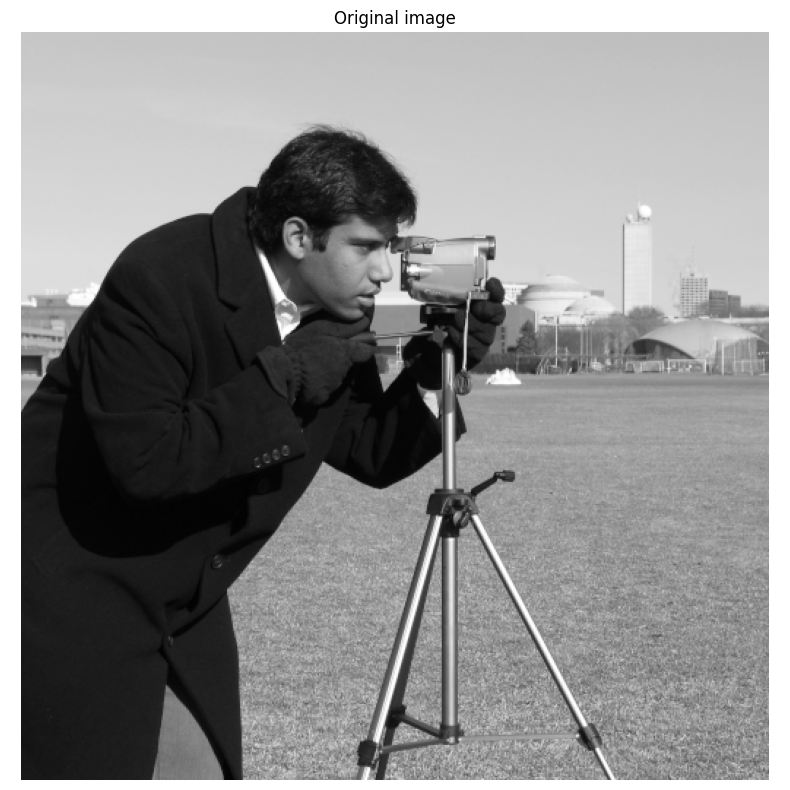

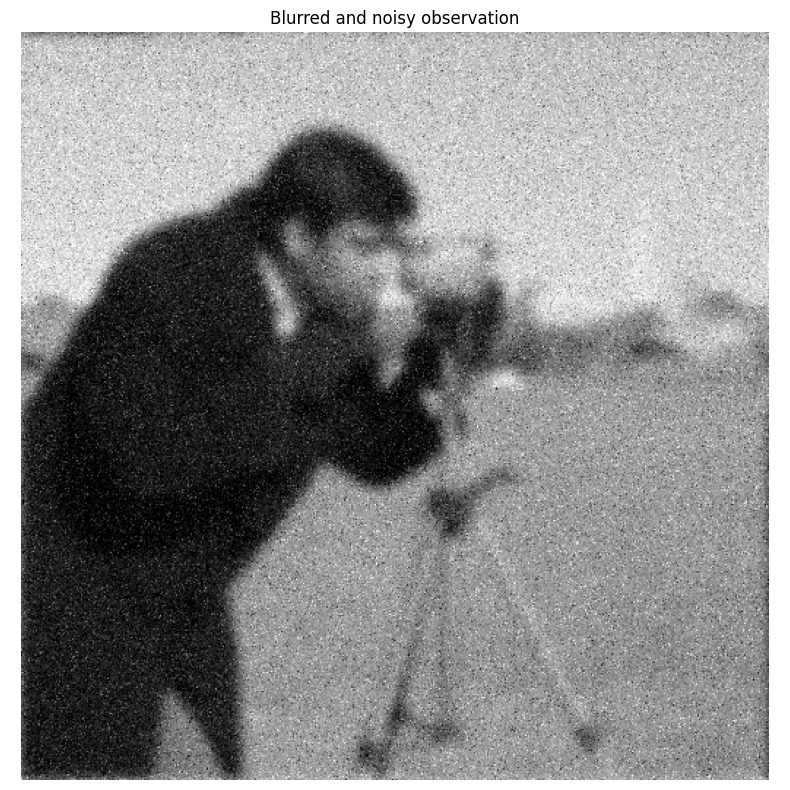

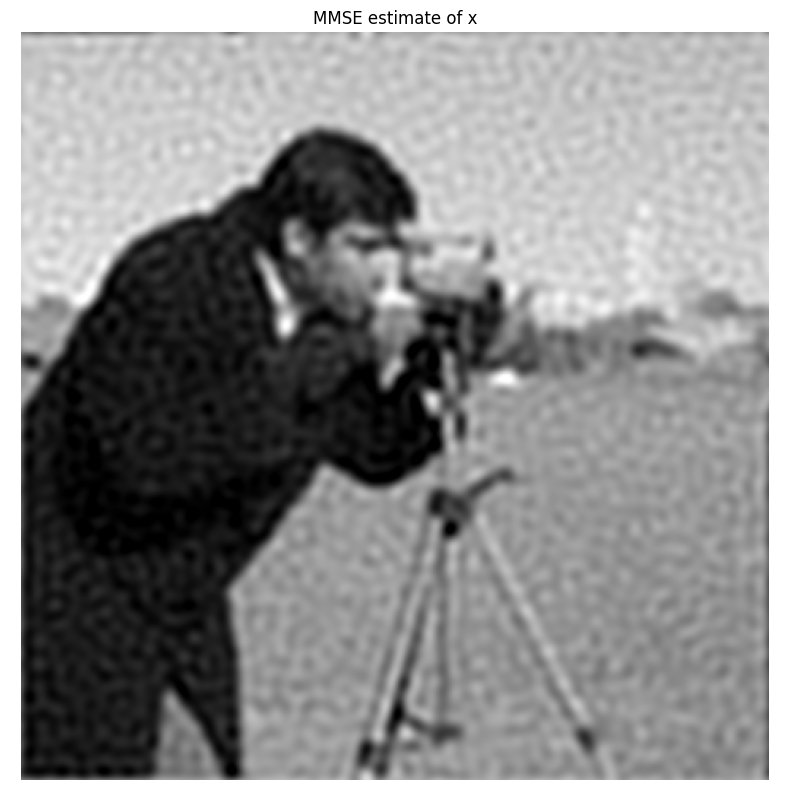

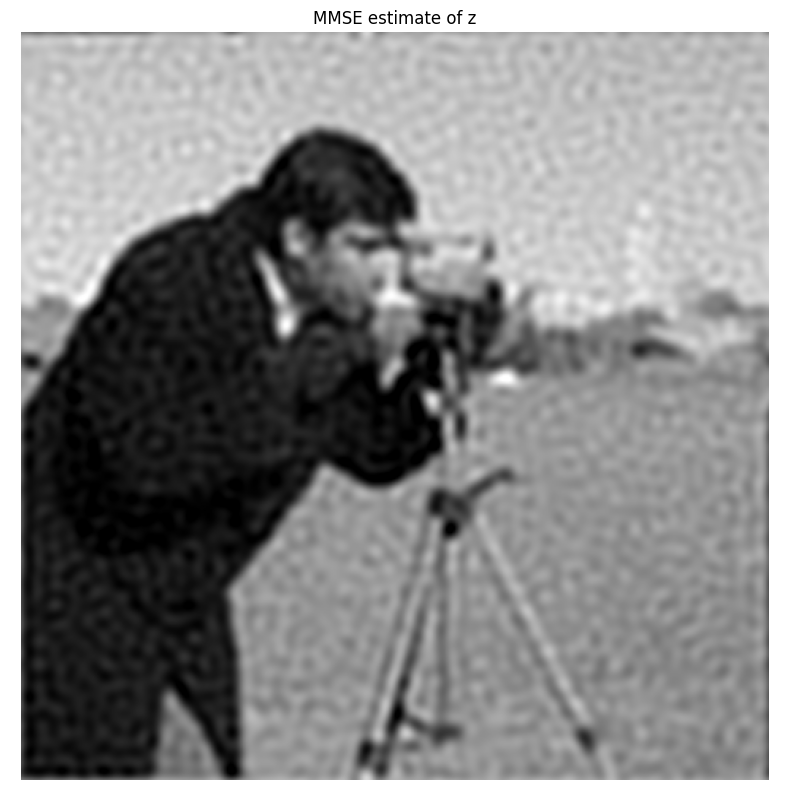

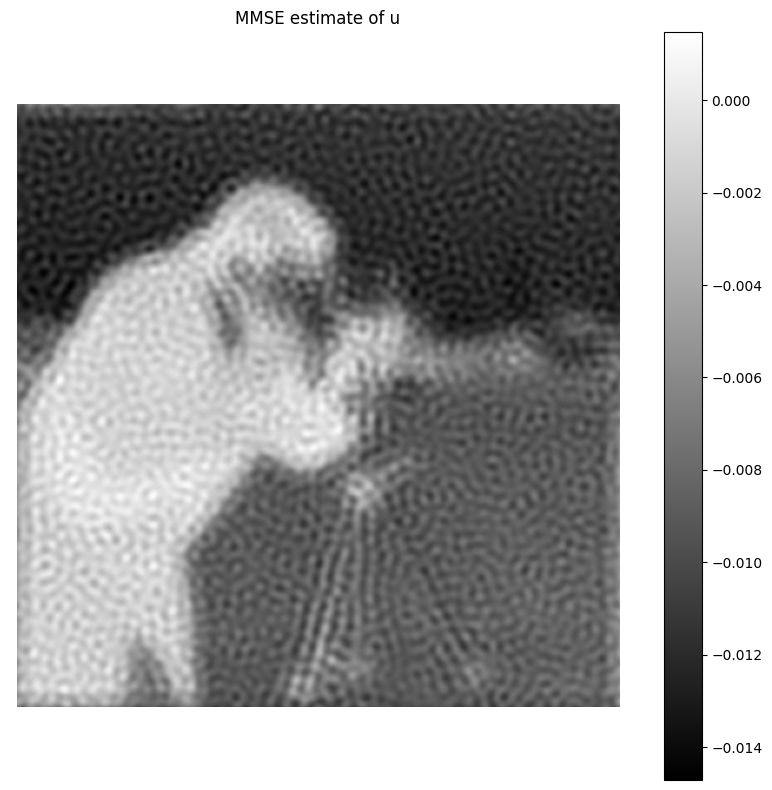

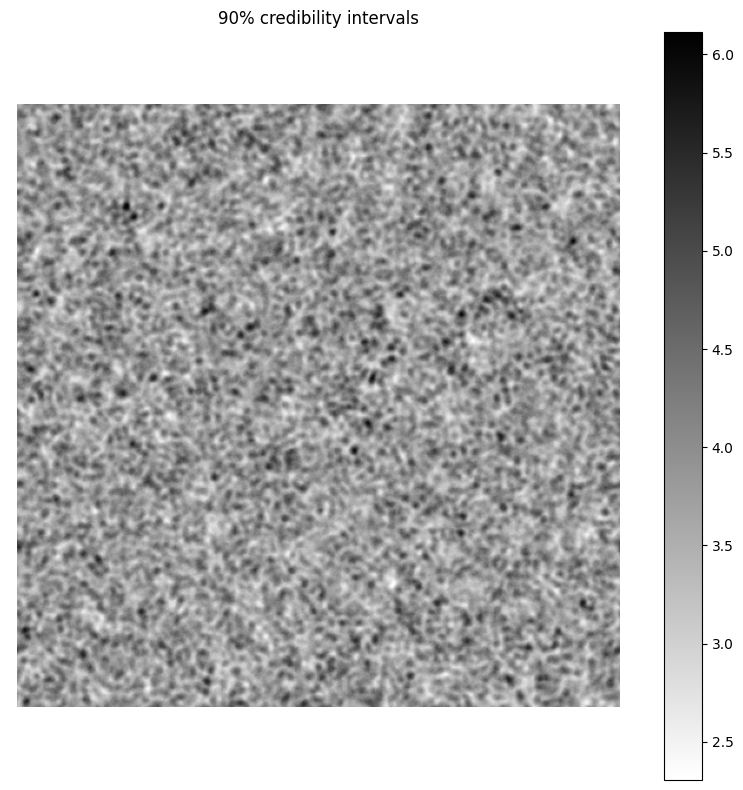

In [9]:
# Plot results
plot_RESULT(y, refl, X_MC, Z_MC, U_MC, N_bi, N_MC, N)